In [77]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import matplotlib.dates as mdates
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages
import gsw  # Gibbs SeaWater (TEOS-10) oceanographic toolbox for seawater property calculations
print('gsw version:', gsw.__version__)

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

gsw version: 3.6.21


# Water Level Data from OWLR at Veteran's Park Retention Pond

In the spreadsheet this is shown at rainfall_0001 data. 

In [78]:


# Paths & time window

data_dir  = "Data"
owlr_path = os.path.join(data_dir, "waterLevel_OWLR_VP_06152026.csv")

start_time = pd.Timestamp("2026-06-07 00:00:00")
end_time   = pd.Timestamp("2026-06-14 23:00:00")


# Load OWLR (rainfall rows only)

cols = [
    "device_id", "timestamp", "unused_1", "data_type",
    "epoch", "OWLR_value_cm", "rain_mm_raw", "col7", "col8"
]

owlr_raw = pd.read_csv(owlr_path, header=None, names=cols)

owlr_raw["timestamp"] = pd.to_datetime(owlr_raw["timestamp"], errors="coerce")
owlr_raw = owlr_raw[owlr_raw["data_type"] == "rainfall_0001"].copy()

# Parse OWLR_value_cm directly; if missing, fall back to payload value in epoch
owlr_raw["OWLR_value_cm"] = pd.to_numeric(owlr_raw["OWLR_value_cm"], errors="coerce")
epoch_value = pd.to_numeric(
    owlr_raw["epoch"].astype(str).str.split(",").str[1],
    errors="coerce"
 )
owlr_raw["OWLR_value_cm"] = owlr_raw["OWLR_value_cm"].fillna(epoch_value)

owlr_raw["WSE_OWLR_cm"] = 826.49568 - owlr_raw["OWLR_value_cm"]

owlr = owlr_raw[
    owlr_raw["timestamp"].notna()
    & (owlr_raw["timestamp"] >= start_time)
    & (owlr_raw["timestamp"] <= end_time)
] .copy()

owlr["timestamp_hour"] = owlr["timestamp"].dt.floor("h")
owlr = owlr.groupby("timestamp_hour", as_index=False)["WSE_OWLR_cm"].mean()

print(f"Window: {start_time} to {end_time}")
print(f"OWLR (rainfall) hourly points: {len(owlr)}")
print(owlr.tail())


Window: 2026-06-07 00:00:00 to 2026-06-14 23:00:00
OWLR (rainfall) hourly points: 192
         timestamp_hour  WSE_OWLR_cm
187 2026-06-14 19:00:00    695.95123
188 2026-06-14 20:00:00    695.26651
189 2026-06-14 21:00:00    695.39151
190 2026-06-14 22:00:00    695.15402
191 2026-06-14 23:00:00    694.66791


In [79]:
# Load air temperature data from CMS dock

airtemp_available = False

try:
    airtemp = (
        pd.read_csv(airtemp_path, skiprows=6)
        .iloc[:, :2]
        .rename(columns=lambda c: c.strip())
    )

    airtemp.columns = ["timestamp", "air_temp_C"]

    airtemp["timestamp"] = pd.to_datetime(
        airtemp["timestamp"], errors="coerce"
    )
    airtemp["air_temp_C"] = pd.to_numeric(
        airtemp["air_temp_C"], errors="coerce"
    )

    airtemp = airtemp.loc[
        airtemp["timestamp"].between(start_time, end_time)
    ].sort_values("timestamp")

    airtemp_available = not airtemp.empty

except Exception as e:
    print(f"Warning: Could not load air temperature: {e}")

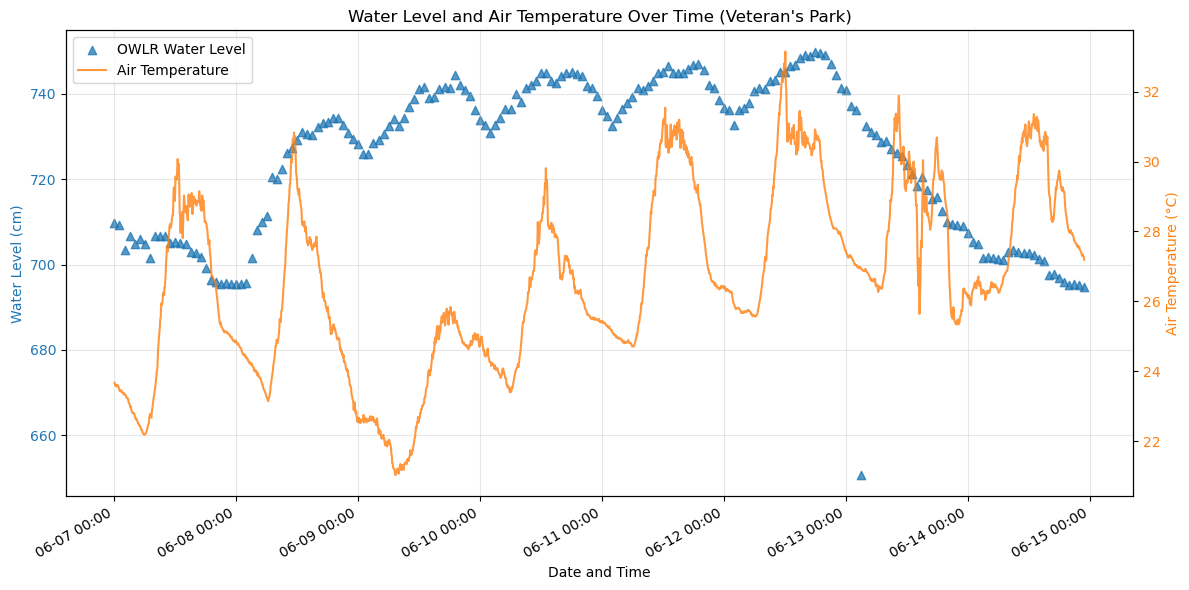

OWLR points shown: 192
Air temperature points shown: 2292


In [80]:

owlr_plot = owlr.sort_values("timestamp_hour")

fig, ax1 = plt.subplots(figsize=(12, 6))

# Water level
ax1.scatter(
    owlr_plot["timestamp_hour"],
    owlr_plot["WSE_OWLR_cm"],
    s=36,
    marker="^",
    alpha=0.75,
    color="tab:blue",
    label="OWLR Water Level"
)

ax1.set_title("Water Level and Air Temperature Over Time (Veteran's Park)")
ax1.set_xlabel("Date and Time")
ax1.set_ylabel("Water Level (cm)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(alpha=0.3)

# Air temperature
if airtemp_available:
    ax2 = ax1.twinx()

    ax2.plot(
        airtemp["timestamp"],
        airtemp["air_temp_C"],
        color="tab:orange",
        linewidth=1.5,
        alpha=0.8,
        label="Air Temperature"
    )

    ax2.set_ylabel(
        "Air Temperature (°C)",
        color="tab:orange"
    )
    ax2.tick_params(axis="y", labelcolor="tab:orange")

# Date formatting
ax1.xaxis.set_major_locator(
    mdates.AutoDateLocator(minticks=6, maxticks=12)
)
ax1.xaxis.set_major_formatter(
    mdates.DateFormatter("%m-%d %H:%M")
)
fig.autofmt_xdate(rotation=30)

# Combined legend
handles, labels = ax1.get_legend_handles_labels()

if airtemp_available:
    h2, l2 = ax2.get_legend_handles_labels()
    handles += h2
    labels += l2

ax1.legend(handles, labels, loc="upper left")

plt.tight_layout()
plt.show()

print(f"OWLR points shown: {len(owlr_plot)}")

if airtemp_available:
    print(f"Air temperature points shown: {len(airtemp)}")
